# Stock Market (S&P 500) Sigma Analysis using the FRED API

This notebook follows the same statistical analysis as the original project, but sources live market data from the Federal Reserve Economic Data (FRED) API instead of a local CSV file.

The analysis pulls the S&P 500 daily series over the last 10 years, ending on yesterday's date. The API key is stored locally in a `.env` file so it stays out of Git and public repositories.

In [1]:
import os
from pathlib import Path
from datetime import date, timedelta

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

## Secure API key configuration

The repository keeps a public-safe template in `.env.example`, while the actual secret remains in a local `.env` file that is ignored by Git. This allows the project to stay portfolio-ready without exposing credentials.

In [2]:
def load_env_file(path):
    values = {}
    if not path.exists():
        return values
    for line in path.read_text(encoding='utf-8').splitlines():
        stripped = line.strip()
        if not stripped or stripped.startswith('#') or '=' not in stripped:
            continue
        key, value = [part.strip() for part in stripped.split('=', 1)]
        values[key] = value
    return values

env_values = load_env_file(Path.cwd() / '.env')
api_key = os.getenv('FRED_API_KEY') or env_values.get('FRED_API_KEY')

if not api_key:
    raise ValueError('FRED_API_KEY is missing. Create a local .env file with your key or copy .env.example to .env.')

print('Loaded FRED API key successfully from local environment settings.')

Loaded FRED API key successfully from local environment settings.


Observation start: 2016-09-22
Observation end: 2026-09-21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2512 non-null   datetime64[ns]
 1   SP500   2512 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.4 KB


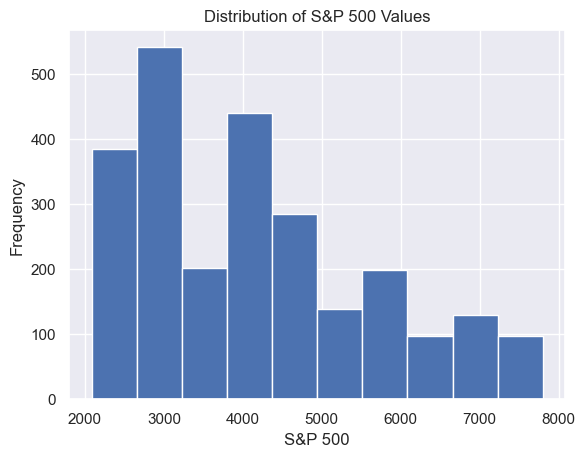

Current close: 7764.7
Mean: 4141.799231687899
Std dev: 1478.891718393603
+1 sigma: 5620.690950081502
+2 sigma: 7099.582668475105
+2.5 sigma: 7839.028527671906
z_score: 2.4497403854876922


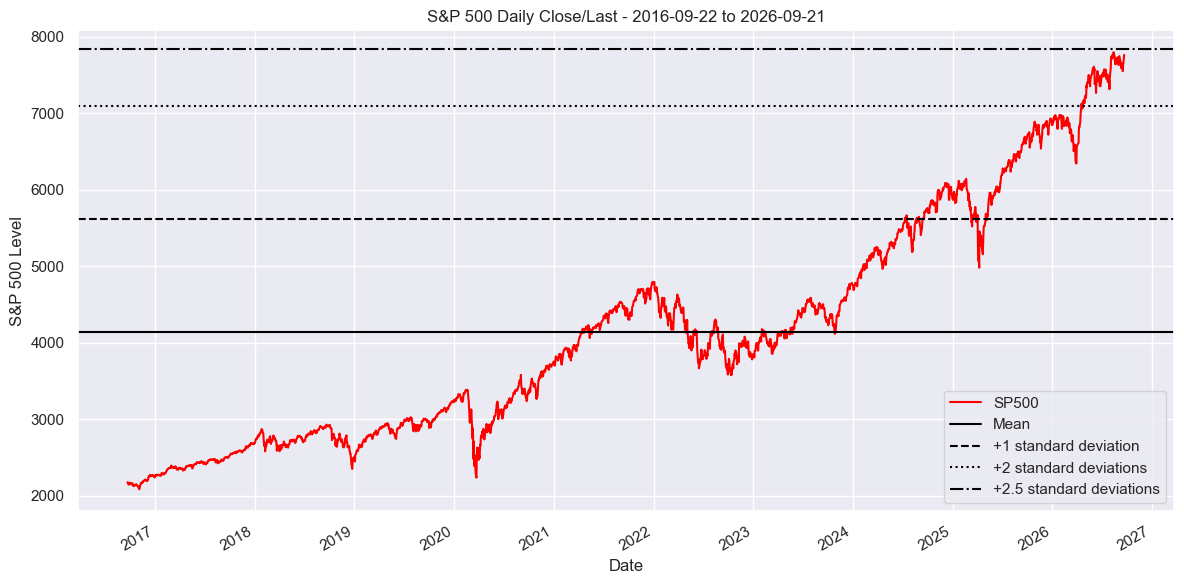

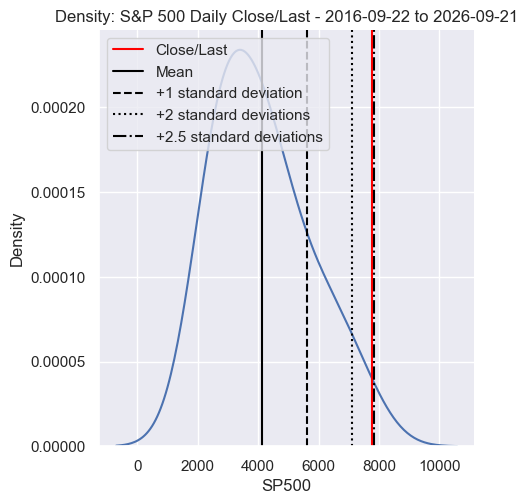

In [3]:
# Set the date window: observation_end is yesterday and observation_start is the same date 10 years ago.
end_date = date.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365 * 10 + 1)

observation_end = end_date.isoformat()
observation_start = start_date.isoformat()

print(f'Observation start: {observation_start}')
print(f'Observation end: {observation_end}')

# Pull the S&P 500 observations from FRED for the requested range.
base_url = 'https://api.stlouisfed.org/fred/series/observations'
params = {
    'series_id': 'SP500',
    'api_key': api_key,
    'file_type': 'json',
    'observation_start': observation_start,
    'observation_end': observation_end,
}

response = requests.get(base_url, params=params, timeout=30)
response.raise_for_status()
payload = response.json()

observations = payload.get('observations', [])
if not observations:
    raise ValueError('No observations returned for the selected date range.')

df = pd.DataFrame(observations)
df['Date'] = pd.to_datetime(df['date'])
df['SP500'] = pd.to_numeric(df['value'], errors='coerce')
df = df[['Date', 'SP500']].dropna().sort_values('Date').reset_index(drop=True)
df.head()

# Clean the data and confirm the time series is ready for analysis.
df = df.dropna(subset=['SP500']).reset_index(drop=True)
df.describe()
df.info()
df.isnull().any()

# Histogram to inspect the distribution of the S&P 500 values.
sns.set()
plt.hist(df['SP500'])
plt.title('Distribution of S&P 500 Values')
plt.xlabel('S&P 500')
plt.ylabel('Frequency')
plt.show()

# Compute the current close, mean, standard deviation, and sigma thresholds.
close_current = df['SP500'].iloc[-1]
close_mean = df['SP500'].mean()
close_sd = df['SP500'].std()

sigma1 = close_mean + close_sd
sigma2 = close_mean + (2 * close_sd)
sigma2_5 = close_mean + (2.5 * close_sd)

print(f'Current close: {close_current}')
print(f'Mean: {close_mean}')
print(f'Std dev: {close_sd}')
print(f'+1 sigma: {sigma1}')
print(f'+2 sigma: {sigma2}')
print(f'+2.5 sigma: {sigma2_5}')

z_score = (close_current - close_mean) / close_sd
z_score
print(f'z_score: {z_score}')

# Visualize the series against its historical mean and sigma thresholds.
date_start = min(df['Date']).date()
date_end = max(df['Date']).date()

if close_current > sigma2:
    c = 'red'
elif close_current > sigma1:
    c = 'orange'
else:
    c = 'green'

df.plot(x='Date', y='SP500', color=c, figsize=(12, 6))
plt.axhline(close_mean, color='black', label='Mean')
plt.axhline(sigma1, color='black', linestyle='--', label='+1 standard deviation')
plt.axhline(sigma2, color='black', linestyle=':', label='+2 standard deviations')
plt.axhline(sigma2_5, color='black', linestyle='-.', label='+2.5 standard deviations')
plt.legend()
plt.title(f'S&P 500 Daily Close/Last - {date_start} to {date_end}')
plt.xlabel('Date')
plt.ylabel('S&P 500 Level')
plt.tight_layout()
plt.show()

sns.displot(df['SP500'], kind='kde', bw_adjust=3.0)
plt.axvline(close_current, color=c, label='Close/Last')
plt.axvline(close_mean, color='black', label='Mean')
plt.axvline(sigma1, color='black', linestyle='--', label='+1 standard deviation')
plt.axvline(sigma2, color='black', linestyle=':', label='+2 standard deviations')
plt.axvline(sigma2_5, color='black', linestyle='-.', label='+2.5 standard deviations')
plt.legend(loc='upper left')
plt.title(f'Density: S&P 500 Daily Close/Last - {date_start} to {date_end}')
plt.show()